# RTB Simulation Study

Evaluate the performance of **twoblock** vs **rtb** (robust twoblock), both dense and sparse, under:

1. **Outlier scenarios**: no outliers, outliers in X only, Y only, or both X and Y — at 0%, 10%, 20% contamination
2. **Uninformative variable scenarios**: no uninformative variables, minority (p_noise < p_signal), majority (p_noise > p_signal)
3. **Dimensionality**: p < n (p_signal=20) and p > n (p_signal=150)

## Methods compared
- **TB dense**: classical twoblock
- **RTB dense**: robust twoblock with relaxed Hampel cutoffs (probp1=0.75, probp2=0.90, probp3=0.95)
- **TB sparse**: sparse twoblock with eta_x=0.5
- **RTB sparse**: robust sparse twoblock with eta_x=0.5, relaxed cutoffs

## Metrics
- $\text{MSE}(B) = \frac{1}{pq} \|  \hat{B} - B_{true} \|_F^2$ — coefficient estimation accuracy
- **F1 score** — variable selection accuracy (for sparse methods on configs with noise variables)

Averaged over 200 repeats.

In [ ]:
import numpy as np
import pandas as pd
from twoblock import twoblock, rtb
import warnings
warnings.filterwarnings('ignore')

## Simulation parameters

In [2]:
# Fixed parameters
n = 100           # number of observations
k = 3             # true latent dimension (= optimal n_components_x)
q = 4             # number of Y variables
sigma_e = 0.5     # X noise std
sigma_f = 0.5     # Y noise std
outlier_shift = 10  # shift magnitude for outlier contamination
n_repeats = 200

# Factors
outlier_proportions = [0.0, 0.10, 0.20]
outlier_types = ['none', 'X', 'Y', 'XY']

# (p_signal, p_noise) configurations
# label -> (p_signal, p_noise)
dim_configs = {
    'p20_noise0':    (20, 0),      # p=20, no noise vars
    'p20_noise10':   (20, 10),     # p=30, minority noise
    'p20_noise80':   (20, 80),     # p=100, majority noise
    'p150_noise0':   (150, 0),     # p=150 > n, no noise vars
    'p150_noise50':  (150, 50),    # p=200 > n, minority noise
    'p150_noise250': (150, 250),   # p=400 > n, majority noise
}

print(f"n={n}, k={k}, q={q}")
print(f"Outlier proportions: {outlier_proportions}")
print(f"Dimension configs:")
for label, (ps, pn) in dim_configs.items():
    print(f"  {label}: p_signal={ps}, p_noise={pn}, p_total={ps+pn}")
print(f"Repeats: {n_repeats}")

n=100, k=3, q=4
Outlier proportions: [0.0, 0.1, 0.2]
Dimension configs:
  p20_noise0: p_signal=20, p_noise=0, p_total=20
  p20_noise10: p_signal=20, p_noise=10, p_total=30
  p20_noise80: p_signal=20, p_noise=80, p_total=100
  p150_noise0: p_signal=150, p_noise=0, p_total=150
  p150_noise50: p_signal=150, p_noise=50, p_total=200
  p150_noise250: p_signal=150, p_noise=250, p_total=400
Repeats: 200


## Data generation functions

In [3]:
def generate_clean_data(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f):
    """
    Generate clean data from a latent variable model.
    
    Returns X (n x p), Y (n x q), B_true (p x q) where p = p_signal + p_noise.
    B_true has zeros in the noise variable rows.
    """
    p = p_signal + p_noise
    
    # Latent scores
    T = rng.standard_normal((n, k))
    
    # Orthonormal loadings for informative variables
    P_raw = rng.standard_normal((p_signal, k))
    P_signal, _ = np.linalg.qr(P_raw)
    P_signal = P_signal[:, :k]
    
    # Inner regression coefficients
    C = rng.standard_normal((k, q))
    
    # Generate informative X block
    E = sigma_e * rng.standard_normal((n, p_signal))
    X_signal = T @ P_signal.T + E
    
    # Generate noise variables
    if p_noise > 0:
        X_noise = sigma_e * rng.standard_normal((n, p_noise))
        X = np.hstack([X_signal, X_noise])
    else:
        X = X_signal
    
    # Generate Y
    F = sigma_f * rng.standard_normal((n, q))
    Y = T @ C + F
    
    # True B: only signal variables contribute
    # B_true = P @ C padded with zeros for noise variables
    B_true = np.zeros((p, q))
    B_true[:p_signal, :] = P_signal @ C
    
    return X, Y, B_true


def contaminate(rng, X, Y, outlier_prop, outlier_type, shift):
    """
    Add outlier contamination to X and/or Y.
    
    Returns contaminated X, Y (copies).
    """
    Xc = X.copy()
    Yc = Y.copy()
    n = X.shape[0]
    n_out = int(np.floor(n * outlier_prop))
    
    if n_out == 0 or outlier_type == 'none':
        return Xc, Yc
    
    # Select outlier indices (first n_out cases)
    idx = rng.choice(n, n_out, replace=False)
    
    if outlier_type in ('X', 'XY'):
        Xc[idx, :] += shift * rng.choice([-1, 1], size=Xc[idx, :].shape)
    
    if outlier_type in ('Y', 'XY'):
        Yc[idx, :] += shift * rng.choice([-1, 1], size=Yc[idx, :].shape)
    
    return Xc, Yc


def mse_B(B_hat, B_true):
    """MSE of coefficient matrix estimate."""
    return np.mean((B_hat - B_true) ** 2)


def varsel_f1(B_hat, B_true, tol=1e-8):
    """
    F1 score for variable selection in X block.
    A variable is 'selected' if any of its coefficients across Y columns exceed tol.
    True support = variables with nonzero rows in B_true.
    """
    true_support = np.any(np.abs(B_true) > tol, axis=1)
    est_support = np.any(np.abs(B_hat) > tol, axis=1)
    
    tp = np.sum(true_support & est_support)
    fp = np.sum(~true_support & est_support)
    fn = np.sum(true_support & ~est_support)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return f1

## Single-repeat runner

In [4]:
eta_x_sim = 0.5  # sparsity parameter for simulation

def run_single(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f,
               outlier_prop, outlier_type, shift):
    """
    Run a single simulation repeat.
    
    Returns dict with MSE and F1 for dense and sparse variants of twoblock and rtb.
    """
    X, Y, B_true = generate_clean_data(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f)
    Xc, Yc = contaminate(rng, X, Y, outlier_prop, outlier_type, shift)
    p = p_signal + p_noise
    has_noise = p_noise > 0
    
    results = {}
    
    # --- Dense methods ---
    # Twoblock dense
    try:
        tb = twoblock(n_components_x=k, n_components_y=min(k, q),
                       scale='std', verbose=False, copy=False)
        tb.fit(Xc, Yc)
        results['tb_mse'] = mse_B(tb.coef_, B_true)
    except Exception:
        results['tb_mse'] = np.nan
    
    # RTB dense relaxed
    try:
        r = rtb(n_components_x=k, n_components_y=min(k, q),
                centre='median', scale='mad', verbose=False, copy=False,
                probp1=0.75, probp2=0.90, probp3=0.95)
        r.fit(Xc, Yc)
        results['rtb_mse'] = mse_B(r.coef_, B_true)
    except Exception:
        results['rtb_mse'] = np.nan
    
    # --- Sparse methods (only meaningful when noise vars exist) ---
    # Sparse twoblock
    try:
        tbs = twoblock(n_components_x=k, n_components_y=min(k, q),
                        sparse=True, eta_x=eta_x_sim, eta_y=0,
                        scale='std', verbose=False, copy=False)
        tbs.fit(Xc, Yc)
        results['tbs_mse'] = mse_B(tbs.coef_, B_true)
        results['tbs_f1'] = varsel_f1(tbs.coef_, B_true) if has_noise else np.nan
    except Exception:
        results['tbs_mse'] = np.nan
        results['tbs_f1'] = np.nan
    
    # Sparse RTB relaxed
    try:
        rs = rtb(n_components_x=k, n_components_y=min(k, q),
                 sparse=True, eta_x=eta_x_sim, eta_y=0,
                 centre='median', scale='mad', verbose=False, copy=False,
                 probp1=0.75, probp2=0.90, probp3=0.95)
        rs.fit(Xc, Yc)
        results['rtbs_mse'] = mse_B(rs.coef_, B_true)
        results['rtbs_f1'] = varsel_f1(rs.coef_, B_true) if has_noise else np.nan
    except Exception:
        results['rtbs_mse'] = np.nan
        results['rtbs_f1'] = np.nan
    
    return results

## Main simulation loop

In [5]:
import time

rng = np.random.default_rng(42)
all_results = []

# Build scenario list
scenarios = []
for dim_label, (p_signal, p_noise) in dim_configs.items():
    for outlier_prop in outlier_proportions:
        for outlier_type in outlier_types:
            if outlier_prop == 0.0 and outlier_type != 'none':
                continue
            if outlier_prop > 0.0 and outlier_type == 'none':
                continue
            scenarios.append((dim_label, p_signal, p_noise, outlier_prop, outlier_type))

metrics = ['tb_mse', 'rtb_mse', 'tbs_mse', 'rtbs_mse', 'tbs_f1', 'rtbs_f1']

print(f"Total scenarios: {len(scenarios)}")
print(f"Total fits: {len(scenarios) * n_repeats * 4}")
t0 = time.time()

for si, (dim_label, p_signal, p_noise, outlier_prop, outlier_type) in enumerate(scenarios):
    collected = {m: [] for m in metrics}
    
    for rep in range(n_repeats):
        res = run_single(rng, n, p_signal, p_noise, k, q, sigma_e, sigma_f,
                         outlier_prop, outlier_type, outlier_shift)
        for m in metrics:
            collected[m].append(res.get(m, np.nan))
    
    row = {
        'dim_config': dim_label,
        'p_signal': p_signal,
        'p_noise': p_noise,
        'p_total': p_signal + p_noise,
        'outlier_prop': outlier_prop,
        'outlier_type': outlier_type,
    }
    for m in metrics:
        row[m + '_mean'] = np.nanmean(collected[m])
        row[m + '_sd'] = np.nanstd(collected[m])
    
    all_results.append(row)
    
    elapsed = time.time() - t0
    f1_str = ""
    if p_noise > 0:
        f1_str = f"  F1: TBs={row['tbs_f1_mean']:.2f} RTBs={row['rtbs_f1_mean']:.2f}"
    print(f"  [{si+1}/{len(scenarios)}] {dim_label}, "
          f"out={outlier_prop:.0%} {outlier_type:>4s} | "
          f"TB={row['tb_mse_mean']:.4f}  RTB={row['rtb_mse_mean']:.4f}  "
          f"TBs={row['tbs_mse_mean']:.4f}  RTBs={row['rtbs_mse_mean']:.4f}"
          f"{f1_str}  ({elapsed:.0f}s)", flush=True)

print(f"\nDone in {time.time()-t0:.0f}s")

Total scenarios: 42
Total fits: 33600
  [1/42] p20_noise0, out=0% none | TB=0.0208  RTB=0.0265  TBs=0.0304  RTBs=0.0357  (4s)
  [2/42] p20_noise0, out=10%    X | TB=0.1242  RTB=0.0272  TBs=0.1352  RTBs=0.0384  (10s)
  [3/42] p20_noise0, out=10%    Y | TB=0.1026  RTB=0.0319  TBs=0.0905  RTBs=0.0431  (14s)
  [4/42] p20_noise0, out=10%   XY | TB=0.1541  RTB=0.0256  TBs=0.1554  RTBs=0.0369  (19s)
  [5/42] p20_noise0, out=20%    X | TB=0.1403  RTB=0.0282  TBs=0.1433  RTBs=0.0391  (25s)
  [6/42] p20_noise0, out=20%    Y | TB=0.2036  RTB=0.0483  TBs=0.1755  RTBs=0.0531  (31s)
  [7/42] p20_noise0, out=20%   XY | TB=0.1564  RTB=0.0277  TBs=0.1570  RTBs=0.0395  (38s)
  [8/42] p20_noise10, out=0% none | TB=0.0203  RTB=0.0240  TBs=0.0218  RTBs=0.0259  F1: TBs=0.80 RTBs=0.80  (41s)
  [9/42] p20_noise10, out=10%    X | TB=0.0850  RTB=0.0247  TBs=0.0924  RTBs=0.0274  F1: TBs=0.70 RTBs=0.80  (47s)
  [10/42] p20_noise10, out=10%    Y | TB=0.1133  RTB=0.0283  TBs=0.0873  RTBs=0.0290  F1: TBs=0.80 RTBs=0

## Results table

In [7]:
df = pd.DataFrame(all_results)

df['scenario'] = df.apply(
    lambda r: "{:.0%} {}".format(r['outlier_prop'], r['outlier_type']), axis=1
)

# MSE table (all 4 methods)
print("=== MSE(B): Dense and Sparse ===")
mse_cols = {
    'TB dense': 'tb_mse_mean', 'RTB dense': 'rtb_mse_mean',
    'TB sparse': 'tbs_mse_mean', 'RTB sparse': 'rtbs_mse_mean',
}
mse_df = df[['dim_config', 'p_total', 'scenario']].copy()
for label, col in mse_cols.items():
    sd_col = col.replace('_mean', '_sd')
    mse_df[label] = df.apply(lambda r: "{:.4f} ({:.4f})".format(r[col], r[sd_col]), axis=1)
display(mse_df)

# F1 table (sparse methods only, where noise vars exist)
print("\n=== Variable selection F1 score (sparse methods, configs with noise vars) ===")
f1_df = df[df['p_noise'] > 0][['dim_config', 'p_total', 'p_signal', 'p_noise', 'scenario']].copy()
f1_df['TB sparse F1'] = df[df['p_noise'] > 0].apply(
    lambda r: "{:.3f} ({:.3f})".format(r['tbs_f1_mean'], r['tbs_f1_sd']), axis=1
).values
f1_df['RTB sparse F1'] = df[df['p_noise'] > 0].apply(
    lambda r: "{:.3f} ({:.3f})".format(r['rtbs_f1_mean'], r['rtbs_f1_sd']), axis=1
).values
display(f1_df)

=== MSE(B): Dense and Sparse ===


,dim_config,p_total,scenario,TB dense,RTB dense,TB sparse,RTB sparse
0,p20_noise0,20,0% none,0.0208 (0.0100),0.0265 (0.0139),0.0304 (0.0151),0.0357 (0.0174)
1,p20_noise0,20,10% X,0.1242 (0.0504),0.0272 (0.0126),0.1352 (0.0538),0.0384 (0.0185)
2,p20_noise0,20,10% Y,0.1026 (0.0518),0.0319 (0.0153),0.0905 (0.0323),0.0431 (0.0218)
3,p20_noise0,20,10% XY,0.1541 (0.0525),0.0256 (0.0112),0.1554 (0.0529),0.0369 (0.0168)
4,p20_noise0,20,20% X,0.1403 (0.0592),0.0282 (0.0138),0.1433 (0.0600),0.0391 (0.0184)
5,p20_noise0,20,20% Y,0.2036 (0.0950),0.0483 (0.0386),0.1755 (0.0674),0.0531 (0.0318)
6,p20_noise0,20,20% XY,0.1564 (0.0645),0.0277 (0.0162),0.1570 (0.0649),0.0395 (0.0216)
7,p20_noise10,30,0% none,0.0203 (0.0089),0.0240 (0.0105),0.0218 (0.0100),0.0259 (0.0119)
8,p20_noise10,30,10% X,0.0850 (0.0359),0.0247 (0.0116),0.0924 (0.0379),0.0274 (0.0133)
9,p20_noise10,30,10% Y,0.1133 (0.0484),0.0283 (0.0201),0.0873 (0.0328),0.0290 (0.0167)



=== Variable selection F1 score (sparse methods, configs with noise vars) ===


,dim_config,p_total,p_signal,p_noise,scenario,TB sparse F1,RTB sparse F1
7,p20_noise10,30,20,10,0% none,0.799 (0.008),0.800 (0.006)
8,p20_noise10,30,20,10,10% X,0.702 (0.070),0.800 (0.005)
9,p20_noise10,30,20,10,10% Y,0.800 (0.004),0.800 (0.016)
10,p20_noise10,30,20,10,10% XY,0.715 (0.074),0.800 (0.010)
11,p20_noise10,30,20,10,20% X,0.694 (0.074),0.799 (0.014)
12,p20_noise10,30,20,10,20% Y,0.800 (0.000),0.798 (0.010)
13,p20_noise10,30,20,10,20% XY,0.704 (0.089),0.800 (0.005)
14,p20_noise80,100,20,80,0% none,0.335 (0.025),0.334 (0.018)
15,p20_noise80,100,20,80,10% X,0.335 (0.050),0.336 (0.028)
16,p20_noise80,100,20,80,10% Y,0.333 (0.000),0.340 (0.045)


## Visualisation

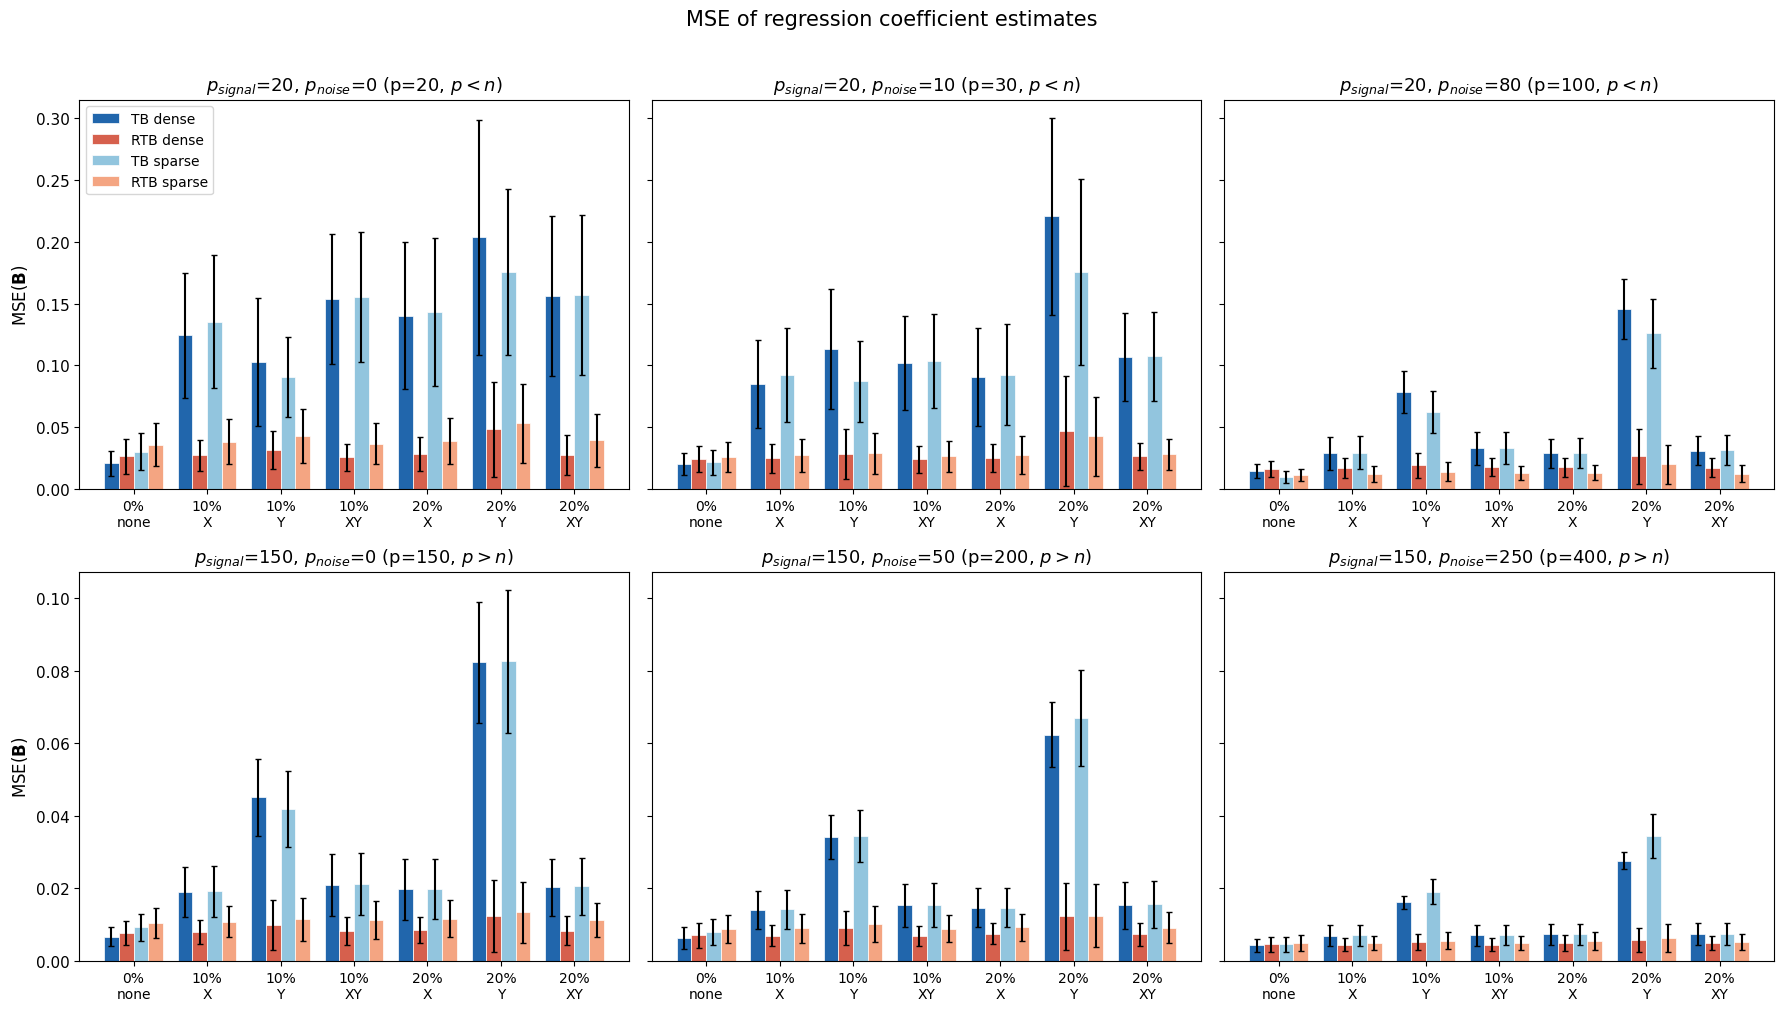

In [11]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
})

# Publication-quality colours with clear distinction
colors_4 = {
    'TB dense':   '#2166ac',   # dark blue
    'RTB dense':  '#d6604d',   # dark red
    'TB sparse':  '#92c5de',   # light blue
    'RTB sparse': '#f4a582',   # light red/salmon
}

n_configs = len(dim_configs)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey='row')

for ax_idx, (dim_label, (p_signal, p_noise)) in enumerate(dim_configs.items()):
    row_idx = ax_idx // 3
    col_idx = ax_idx % 3
    ax = axes[row_idx, col_idx]
    sub = df[df['dim_config'] == dim_label].copy()
    
    sub['label'] = sub.apply(
        lambda r: "{:.0%}\n{}".format(r['outlier_prop'], r['outlier_type']), axis=1
    )
    
    x = np.arange(len(sub))
    width = 0.2
    
    for i, (method, col) in enumerate([
        ('TB dense', 'tb_mse'), ('RTB dense', 'rtb_mse'),
        ('TB sparse', 'tbs_mse'), ('RTB sparse', 'rtbs_mse')
    ]):
        offset = (i - 1.5) * width
        ax.bar(x + offset, sub[col + '_mean'], width,
               yerr=sub[col + '_sd'], label=method, 
               color=colors_4[method], edgecolor='white', linewidth=0.5, capsize=2)
    
    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'].values)
    ptot = p_signal + p_noise
    regime = '$p < n$' if ptot <= 100 else '$p > n$'
    ax.set_title("$p_{{signal}}$={}, $p_{{noise}}$={} (p={}, {})".format(
        p_signal, p_noise, ptot, regime))
    if col_idx == 0:
        ax.set_ylabel('MSE($\\mathbf{B}$)')
    if ax_idx == 0:
        ax.legend(loc='upper left')

fig.suptitle('MSE of regression coefficient estimates', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Heatmap: RTB/Twoblock MSE ratio

Values < 1 mean RTB outperforms twoblock; values > 1 mean twoblock is better.
Shown for both dense and sparse variants.

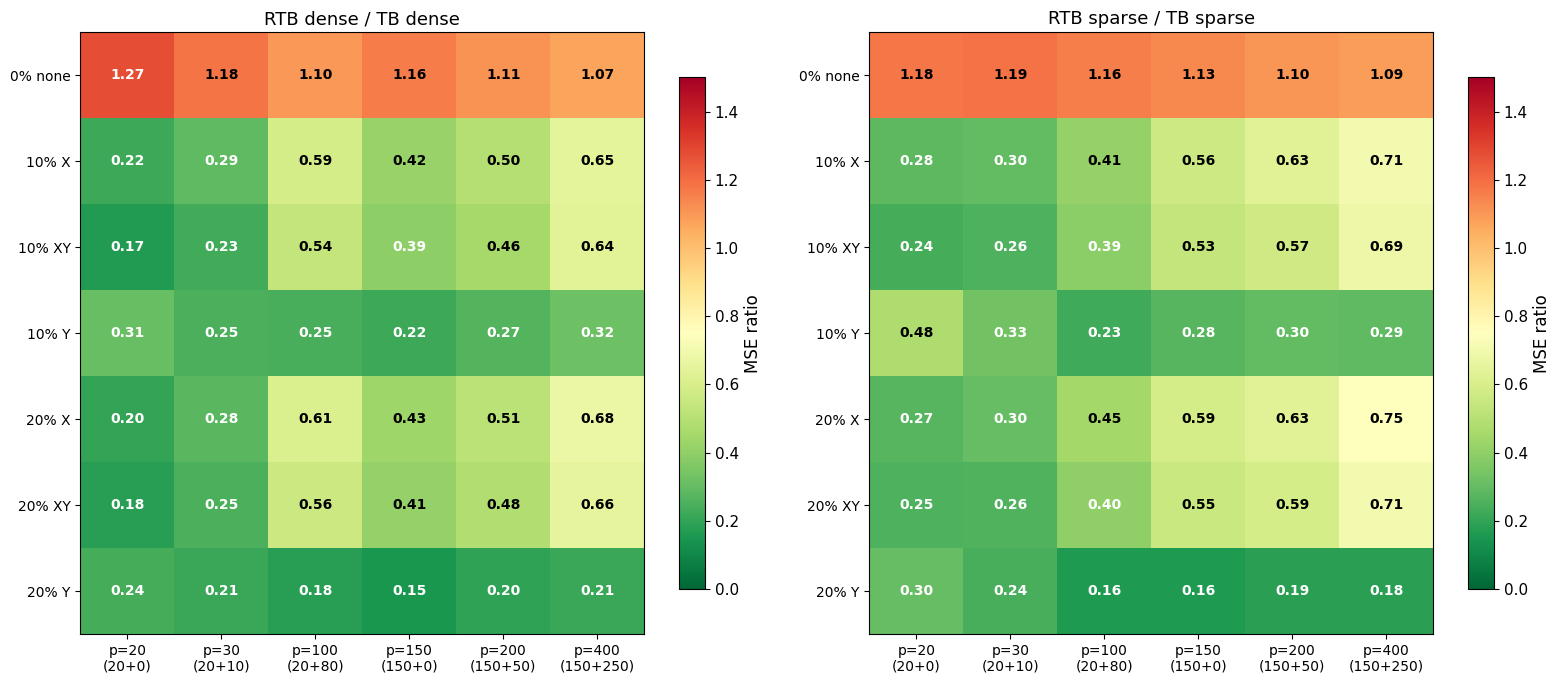

In [12]:
# Compute MSE ratios
df['RTB_dense/TB_dense'] = (df['rtb_mse_mean'] / df['tb_mse_mean']).round(3)
df['RTB_sparse/TB_sparse'] = (df['rtbs_mse_mean'] / df['tbs_mse_mean']).round(3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, title, cmap_color in [
    (ax1, 'RTB_dense/TB_dense', 'RTB dense / TB dense', 'RdYlGn_r'),
    (ax2, 'RTB_sparse/TB_sparse', 'RTB sparse / TB sparse', 'RdYlGn_r')
]:
    pivot = df.pivot_table(index='scenario', columns='dim_config', values=col)
    pivot = pivot[[c for c in dim_configs.keys() if c in pivot.columns]]
    
    col_labels = []
    for c in pivot.columns:
        ps, pn = dim_configs[c]
        col_labels.append("p={}\n({}+{})".format(ps + pn, ps, pn))
    
    im = ax.imshow(pivot.values, cmap=cmap_color, aspect='auto', vmin=0, vmax=1.5)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)
    ax.set_title(title, fontsize=13)
    
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, "{:.2f}".format(val), ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white' if val > 1.2 or val < 0.4 else 'black')
    
    plt.colorbar(im, ax=ax, shrink=0.85, label='MSE ratio')

plt.tight_layout()
plt.show()

## Variable selection: F1 score (sparse methods only)

F1 score measures how well the sparse methods recover the true support (signal variables vs noise variables). Only computed for configurations with noise variables.

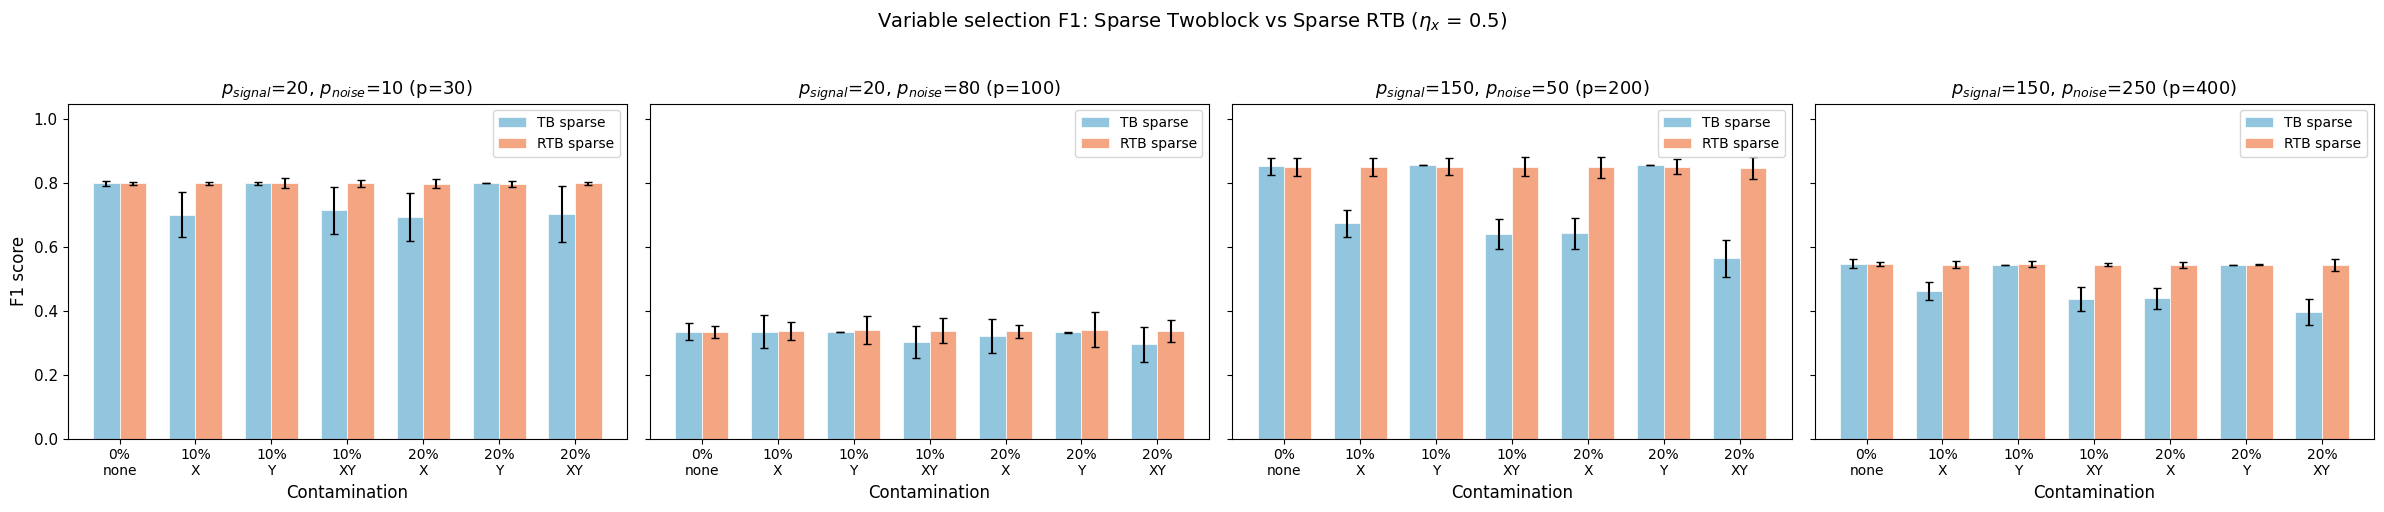

In [13]:
# F1 score bar charts for configs with noise variables
noise_configs = {k: v for k, v in dim_configs.items() if v[1] > 0}
n_panels = len(noise_configs)

fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

for ax_idx, (dim_label, (ps, pn)) in enumerate(noise_configs.items()):
    ax = axes[ax_idx]
    sub = df[df['dim_config'] == dim_label].copy()
    sub['label'] = sub.apply(
        lambda r: "{:.0%}\n{}".format(r['outlier_prop'], r['outlier_type']), axis=1
    )
    
    x = np.arange(len(sub))
    width = 0.35
    
    ax.bar(x - width/2, sub['tbs_f1_mean'], width,
           yerr=sub['tbs_f1_sd'], label='TB sparse', 
           color='#92c5de', edgecolor='white', linewidth=0.5, capsize=3)
    ax.bar(x + width/2, sub['rtbs_f1_mean'], width,
           yerr=sub['rtbs_f1_sd'], label='RTB sparse', 
           color='#f4a582', edgecolor='white', linewidth=0.5, capsize=3)
    
    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'].values)
    ax.set_title("$p_{{signal}}$={}, $p_{{noise}}$={} (p={})".format(ps, pn, ps+pn))
    ax.set_xlabel('Contamination')
    if ax_idx == 0:
        ax.set_ylabel('F1 score')
    ax.set_ylim(0, 1.05)
    ax.legend()

fig.suptitle('Variable selection F1: Sparse Twoblock vs Sparse RTB ($\\eta_x$ = {})'.format(eta_x_sim), 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## MSE as a function of outlier fraction

Fixed: p_signal=20, p_noise=80, k=3, q=4. Outlier type: XY (both blocks).
Vary outlier fraction from 0% to 40% in steps of 5%.

In [16]:
# MSE vs outlier fraction
rng_of = np.random.default_rng(123)
outlier_fracs = np.arange(0, 0.6, 0.05)
p_signal_of, p_noise_of = 20, 80
n_rep_of = 200

methods_of = ['tb_mse', 'rtb_mse', 'tbs_mse', 'rtbs_mse']
results_of = {m: {'mean': [], 'sd': []} for m in methods_of}

t0 = time.time()
for frac in outlier_fracs:
    collected = {m: [] for m in methods_of}
    for rep in range(n_rep_of):
        res = run_single(rng_of, n, p_signal_of, p_noise_of, k, q, sigma_e, sigma_f,
                         frac, 'XY' if frac > 0 else 'none', outlier_shift)
        for m in methods_of:
            collected[m].append(res.get(m, np.nan))
    for m in methods_of:
        results_of[m]['mean'].append(np.nanmean(collected[m]))
        results_of[m]['sd'].append(np.nanstd(collected[m]))
    print("  frac={:.0%}  TB={:.4f}  RTB={:.4f}  TBs={:.4f}  RTBs={:.4f}  ({:.0f}s)".format(
        frac, results_of['tb_mse']['mean'][-1], results_of['rtb_mse']['mean'][-1],
        results_of['tbs_mse']['mean'][-1], results_of['rtbs_mse']['mean'][-1],
        time.time() - t0), flush=True)

print("Done in {:.0f}s".format(time.time() - t0))

  frac=0%  TB=0.0143  RTB=0.0157  TBs=0.0094  RTBs=0.0110  (24s)
  frac=5%  TB=0.0282  RTB=0.0154  TBs=0.0284  RTBs=0.0110  (50s)
  frac=10%  TB=0.0316  RTB=0.0167  TBs=0.0319  RTBs=0.0118  (83s)
  frac=15%  TB=0.0300  RTB=0.0162  TBs=0.0304  RTBs=0.0118  (125s)
  frac=20%  TB=0.0296  RTB=0.0164  TBs=0.0300  RTBs=0.0120  (159s)
  frac=25%  TB=0.0324  RTB=0.0184  TBs=0.0328  RTBs=0.0136  (195s)
  frac=30%  TB=0.0315  RTB=0.0200  TBs=0.0320  RTBs=0.0149  (259s)
  frac=35%  TB=0.0309  RTB=0.0200  TBs=0.0313  RTBs=0.0160  (329s)
  frac=40%  TB=0.0323  RTB=0.0232  TBs=0.0326  RTBs=0.0202  (416s)
  frac=45%  TB=0.0317  RTB=0.0240  TBs=0.0320  RTBs=0.0220  (518s)
  frac=50%  TB=0.0308  RTB=0.0228  TBs=0.0311  RTBs=0.0259  (631s)
  frac=55%  TB=0.0325  RTB=0.0317  TBs=0.0328  RTBs=0.0319  (706s)
Done in 706s


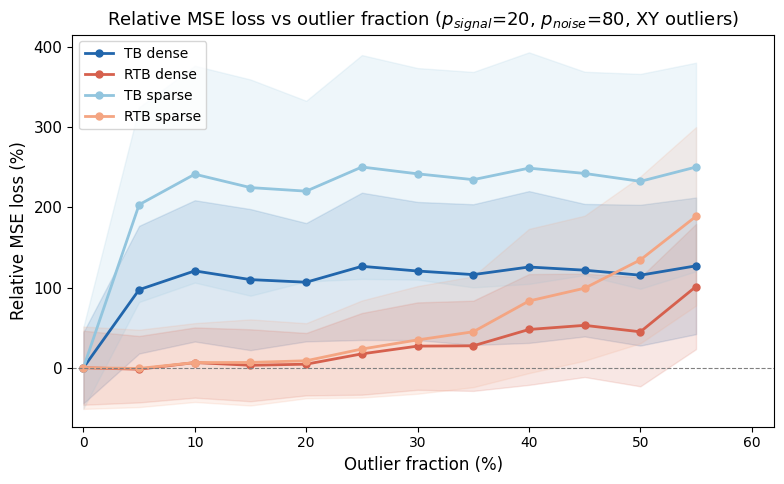

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

labels_of = {'tb_mse': 'TB dense', 'rtb_mse': 'RTB dense',
             'tbs_mse': 'TB sparse', 'rtbs_mse': 'RTB sparse'}

# Baseline MSE at 0% outliers for each method
baselines = {m: results_of[m]['mean'][0] for m in methods_of}

for m, label in labels_of.items():
    means = np.array(results_of[m]['mean'])
    sds = np.array(results_of[m]['sd'])
    # Relative MSE loss (%) = (MSE - MSE_baseline) / MSE_baseline * 100
    rel_loss = (means - baselines[m]) / baselines[m] * 100
    rel_loss_sd = sds / baselines[m] * 100
    ax.plot(outlier_fracs * 100, rel_loss, 'o-', label=label, color=colors_4[label], linewidth=2, markersize=5)
    ax.fill_between(outlier_fracs * 100, rel_loss - rel_loss_sd, rel_loss + rel_loss_sd,
                    alpha=0.15, color=colors_4[label])

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Outlier fraction (%)')
ax.set_ylabel('Relative MSE loss (%)')
ax.set_title('Relative MSE loss vs outlier fraction ($p_{{signal}}$={}, $p_{{noise}}$={}, XY outliers)'.format(
    p_signal_of, p_noise_of))
ax.legend()
ax.set_xlim(-1, 62)
plt.tight_layout()
plt.show()

## MSE as a function of the fraction of uninformative variables

Fixed: p_signal=20, k=3, q=4, 20% XY outliers.
Vary p_noise from 0 to 180 (i.e., noise fraction from 0% to 90%).

In [21]:
# MSE vs noise variable fraction
rng_nf = np.random.default_rng(456)
p_signal_nf = 20
p_noise_values = [0, 5, 10, 20, 40, 60, 80, 100, 140, 180]
noise_fracs = [pn / (p_signal_nf + pn) for pn in p_noise_values]
outlier_prop_nf = 0.20
n_rep_nf = 200

methods_nf = ['tb_mse', 'rtb_mse', 'tbs_mse', 'rtbs_mse']
results_nf = {m: {'mean': [], 'sd': []} for m in methods_nf}

t0 = time.time()
for pn in p_noise_values:
    collected = {m: [] for m in methods_nf}
    for rep in range(n_rep_nf):
        res = run_single(rng_nf, n, p_signal_nf, pn, k, q, sigma_e, sigma_f,
                         outlier_prop_nf, 'XY', outlier_shift)
        for m in methods_nf:
            collected[m].append(res.get(m, np.nan))
    for m in methods_nf:
        results_nf[m]['mean'].append(np.nanmean(collected[m]))
        results_nf[m]['sd'].append(np.nanstd(collected[m]))
    frac = pn / (p_signal_nf + pn)
    print("  p_noise={:3d} ({:.0%} noise)  TB={:.4f}  RTB={:.4f}  TBs={:.4f}  RTBs={:.4f}  ({:.0f}s)".format(
        pn, frac, results_nf['tb_mse']['mean'][-1], results_nf['rtb_mse']['mean'][-1],
        results_nf['tbs_mse']['mean'][-1], results_nf['rtbs_mse']['mean'][-1],
        time.time() - t0), flush=True)

print("Done in {:.0f}s".format(time.time() - t0))

  p_noise=  0 (0% noise)  TB=0.1592  RTB=0.0260  TBs=0.1592  RTBs=0.0374  (7s)
  p_noise=  5 (20% noise)  TB=0.1234  RTB=0.0253  TBs=0.1238  RTBs=0.0299  (14s)
  p_noise= 10 (33% noise)  TB=0.1052  RTB=0.0245  TBs=0.1059  RTBs=0.0270  (20s)
  p_noise= 20 (50% noise)  TB=0.0753  RTB=0.0225  TBs=0.0759  RTBs=0.0208  (26s)
  p_noise= 40 (67% noise)  TB=0.0512  RTB=0.0209  TBs=0.0519  RTBs=0.0168  (34s)
  p_noise= 60 (75% noise)  TB=0.0385  RTB=0.0189  TBs=0.0390  RTBs=0.0139  (44s)
  p_noise= 80 (80% noise)  TB=0.0307  RTB=0.0174  TBs=0.0312  RTBs=0.0121  (82s)
  p_noise=100 (83% noise)  TB=0.0259  RTB=0.0160  TBs=0.0262  RTBs=0.0117  (149s)
  p_noise=140 (88% noise)  TB=0.0189  RTB=0.0131  TBs=0.0191  RTBs=0.0097  (231s)
  p_noise=180 (90% noise)  TB=0.0157  RTB=0.0118  TBs=0.0159  RTBs=0.0085  (281s)
Done in 281s


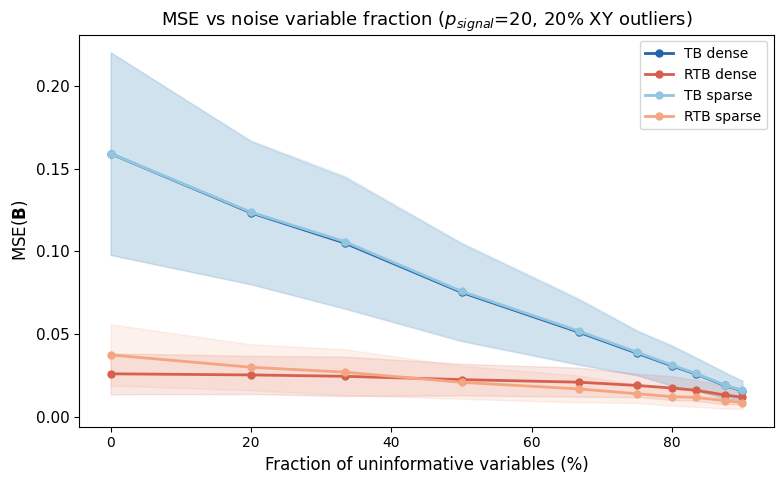

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

noise_pcts = [100 * pn / (p_signal_nf + pn) for pn in p_noise_values]

for m, label in labels_of.items():
    means = np.array(results_nf[m]['mean'])
    sds = np.array(results_nf[m]['sd'])
    ax.plot(noise_pcts, means, 'o-', label=label, color=colors_4[label], linewidth=2, markersize=5)
    ax.fill_between(noise_pcts, means - sds, means + sds, alpha=0.15, color=colors_4[label])

ax.set_xlabel('Fraction of uninformative variables (%)')
ax.set_ylabel('MSE($\\mathbf{B}$)')
ax.set_title('MSE vs noise variable fraction ($p_{{signal}}$={}, 20% XY outliers)'.format(p_signal_nf))
ax.legend()
plt.tight_layout()
plt.show()